<a href="https://colab.research.google.com/github/aazeeem11/Machine-Learning-projects-/blob/main/stock_price_prediction_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"/content/GOOG.csv")
df.head()

,symbol,date,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor
0,GOOG,2016-06-14 00:00:00+00:00,718.27,722.47,713.1200,716.48,1306065,718.27,722.47,713.1200,716.48,1306065,0.0,1.0
1,GOOG,2016-06-15 00:00:00+00:00,718.92,722.98,717.3100,719.00,1214517,718.92,722.98,717.3100,719.00,1214517,0.0,1.0
2,GOOG,2016-06-16 00:00:00+00:00,710.36,716.65,703.2600,714.91,1982471,710.36,716.65,703.2600,714.91,1982471,0.0,1.0
3,GOOG,2016-06-17 00:00:00+00:00,691.72,708.82,688.4515,708.65,3402357,691.72,708.82,688.4515,708.65,3402357,0.0,1.0
4,GOOG,2016-06-20 00:00:00+00:00,693.71,702.48,693.4100,698.77,2082538,693.71,702.48,693.4100,698.77,2082538,0.0,1.0


In [8]:
df = df.sort_index()

In [9]:
data = df[['close']].values

# Normalize data between 0 and 1
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)


In [10]:
def create_sequences(data, time_step=60):
    X, y = [], []
    for i in range(time_step, len(data)):
        X.append(data[i-time_step:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

time_step = 60
X, y = create_sequences(scaled_data, time_step)

# Reshape X for LSTM [samples, time_steps, features]
X = X.reshape((X.shape[0], X.shape[1], 1))


In [11]:
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


In [12]:
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=1))  # Output: predicted close price

model.compile(optimizer='adam', loss='mean_squared_error')


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [13]:
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test), verbose=1)


Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 79ms/step - loss: 0.0232 - val_loss: 0.0133
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - loss: 0.0022 - val_loss: 0.0090
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - loss: 0.0013 - val_loss: 0.0028
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - loss: 0.0012 - val_loss: 0.0036
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - loss: 9.3438e-04 - val_loss: 0.0029
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - loss: 9.4385e-04 - val_loss: 0.0023
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - loss: 9.6864e-04 - val_loss: 0.0048
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - loss: 9.6574e-04 - val_loss: 0.0031
Epoch 9/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - loss: 8.7752e-04 - val_loss: 0.0057
Epoch 10/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - loss: 9.4621e-04 - val_loss: 0.0048
Epoch 11/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - loss: 8.5201e-04 - val_loss: 0.0050
Epoch 12/50
30/30 ━━━━━━━━━━━━━━━━

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 146ms/step


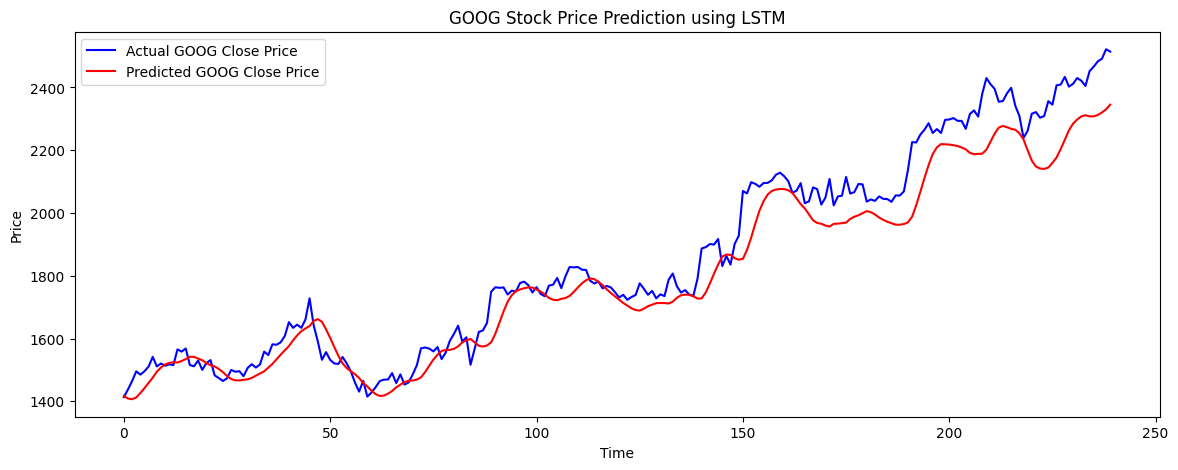

In [15]:
predicted = model.predict(X_test)
predicted_prices = scaler.inverse_transform(predicted)
actual_prices = scaler.inverse_transform(y_test.reshape(-1, 1))

plt.figure(figsize=(14,5))
plt.plot(actual_prices, color='blue', label='Actual GOOG Close Price')
plt.plot(predicted_prices, color='red', label='Predicted GOOG Close Price')
plt.title('GOOG Stock Price Prediction using LSTM')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()
